# PTB-XL ECG Dataset - Data Exploration

**Course:** AAI-501 - Introduction to AI and Machine Learning  
**Project:** ECG Arrhythmia Classification  
**Part:** 1 - Data Preparation & EDA  
**Author:** Ashok Bhairwal

## Objectives
1. Load and understand the PTB-XL dataset structure
2. Explore metadata and patient demographics
3. Analyze diagnostic label distribution
4. Visualize sample ECG signals
5. Identify data quality issues

In [41]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import wfdb
import ast
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

print("Libraries loaded successfully!")

Libraries loaded successfully!


## 1. Load Dataset

In [42]:
# Define paths
DATA_PATH = Path('../data/raw/physionet.org/files/ptb-xl/1.0.3')
SAMPLING_RATE = 100  # Use 100 Hz for faster processing
# Save enhanced metadata
OUTPUT_PATH = Path('../data/preprocessed')
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

# Load metadata
df = pd.read_csv(DATA_PATH / 'ptbxl_database.csv', index_col='ecg_id')
print(f"Dataset shape: {df.shape}")
print(f"Total ECG records: {len(df)}")
print(f"Total patients: {df['patient_id'].nunique()}")

df.head()
df.info()

Dataset shape: (21799, 27)
Total ECG records: 21799
Total patients: 18869
<class 'pandas.DataFrame'>
Index: 21799 entries, 1 to 21837
Data columns (total 27 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   patient_id                    21799 non-null  float64
 1   age                           21799 non-null  float64
 2   sex                           21799 non-null  int64  
 3   height                        6974 non-null   float64
 4   weight                        9421 non-null   float64
 5   nurse                         20326 non-null  float64
 6   site                          21782 non-null  float64
 7   device                        21799 non-null  str    
 8   recording_date                21799 non-null  str    
 9   report                        21799 non-null  str    
 10  scp_codes                     21799 non-null  str    
 11  heart_axis                    13331 non-null  str    
 12  in

In [43]:
# Column names and descriptions
print("\nColumn Names:")
for i, col in enumerate(df.columns, 1):
    print(f"{i:2d}. {col}")


Column Names:
 1. patient_id
 2. age
 3. sex
 4. height
 5. weight
 6. nurse
 7. site
 8. device
 9. recording_date
10. report
11. scp_codes
12. heart_axis
13. infarction_stadium1
14. infarction_stadium2
15. validated_by
16. second_opinion
17. initial_autogenerated_report
18. validated_by_human
19. baseline_drift
20. static_noise
21. burst_noise
22. electrodes_problems
23. extra_beats
24. pacemaker
25. strat_fold
26. filename_lr
27. filename_hr


In [44]:
selected_columns = [
    "patient_id", "age", "sex", "height", "weight", "nurse", "site",
    "device", "recording_date", "report", "scp_codes", "heart_axis",
    "infarction_stadium1", "infarction_stadium2", "validated_by",
    "second_opinion", "initial_autogenerated_report", "validated_by_human",
    "baseline_drift", "static_noise", "burst_noise",
    "electrodes_problems", "extra_beats", "pacemaker",
    "strat_fold", "filename_lr", "filename_hr"
]

# Only select columns that actually exist in the dataframe
existing_cols = [col for col in selected_columns if col in df.columns]
missing_cols = [col for col in selected_columns if col not in df.columns]

if missing_cols:
    print(f"Note: The following columns don't exist yet and will be skipped: {missing_cols}")
    print(f"      These will be added after diagnostic labels are created in Section 3")

# Save metadata with available columns
df_metadata = df[existing_cols].copy()
df_metadata.to_csv(OUTPUT_PATH / 'metadata_with_labels.csv')
print(f"Shape: {df_metadata.shape}")
print(f"Columns saved: {len(existing_cols)}/{len(selected_columns)}")
print(f"Records: {len(df_metadata):,} ECG records from {df_metadata['patient_id'].nunique():,} patients")

Shape: (21799, 27)
Columns saved: 27/27
Records: 21,799 ECG records from 18,869 patients


## 2.  Data Cleaning

#### 2a. Identifying and Removing Missing Data

This step removes ECG records for patients whose required ECG files (.dat and .hea) are missing.

In [45]:
# Check for missing files AND filter dataset
missing_dat = []
missing_hea = []
missing_both = []
valid_records = []
print("="*70)
# Check each record
for ecg_id, row in df.iterrows():
    patient_id = int(row['patient_id'])
    filename_lr = row['filename_lr']
    
    # Construct file paths
    base_path = DATA_PATH / filename_lr
    dat_file = Path(str(base_path) + '.dat')
    hea_file = Path(str(base_path) + '.hea')
    
    # Check existence
    dat_exists = dat_file.exists()
    hea_exists = hea_file.exists()
    
    # Categorize
    if not dat_exists and not hea_exists:
        missing_both.append((ecg_id, patient_id))
    elif not dat_exists:
        missing_dat.append((ecg_id, patient_id))
    elif not hea_exists:
        missing_hea.append((ecg_id, patient_id))
    else:
        valid_records.append(ecg_id)

# Get unique patient IDs with any missing file
all_missing_patients = set()
for ecg_id, patient_id in missing_dat + missing_hea + missing_both:
    all_missing_patients.add(patient_id)
all_missing_patients = sorted(list(all_missing_patients))

# Print summary
print(f"RESULTS:")
print("="*70)
print(f"Total records checked:      {len(df):,}")
print(f"Valid records (both files): {len(valid_records):,}")
print(f"Missing .dat only:          {len(missing_dat)} records")
print(f"Missing .hea only:          {len(missing_hea)} records")
print(f"Missing both files:         {len(missing_both)} records")
print(f"Total records to remove:    {len(missing_dat) + len(missing_hea) + len(missing_both)}")
print(f"Unique patient IDs affected: {len(all_missing_patients)}")


# FILTER DATASET - Remove records with missing files
print("\n" + "="*70)
print("FILTERING DATASET")
print("="*70)

df_original = df.copy()
original_count = len(df)

# Keep only valid records
df = df.loc[valid_records]

removed_count = original_count - len(df)

print(f"\nOriginal records:  {original_count:,}")
print(f"Records removed:   {removed_count:,}")
print(f"Remaining records: {len(df):,}")
print(f"Remaining patients: {df['patient_id'].nunique():,}")
print("="*70)

print(f"\nFiltered Dataset shape: {df.shape}")
df.head()

RESULTS:
Total records checked:      21,799
Valid records (both files): 21,762
Missing .dat only:          19 records
Missing .hea only:          18 records
Missing both files:         0 records
Total records to remove:    37
Unique patient IDs affected: 37

FILTERING DATASET

Original records:  21,799
Records removed:   37
Remaining records: 21,762
Remaining patients: 18,843

Filtered Dataset shape: (21762, 27)


,patient_id,age,sex,height,weight,nurse,site,device,recording_date,report,...,validated_by_human,baseline_drift,static_noise,burst_noise,electrodes_problems,extra_beats,pacemaker,strat_fold,filename_lr,filename_hr
ecg_id,,,,,,,,,,,,,,,,,,,,,
1,15709.0,56.0,1,NaN,63.0,2.0,0.0,CS-12 E,1984-11-09 09:17:34,sinusrhythmus periphere niederspannung,...,True,NaN,", I-V1,",NaN,NaN,NaN,NaN,3,records100/00000/00001_lr,records500/00000/00001_hr
2,13243.0,19.0,0,NaN,70.0,2.0,0.0,CS-12 E,1984-11-14 12:55:37,sinusbradykardie sonst normales ekg,...,True,NaN,NaN,NaN,NaN,NaN,NaN,2,records100/00000/00002_lr,records500/00000/00002_hr
3,20372.0,37.0,1,NaN,69.0,2.0,0.0,CS-12 E,1984-11-15 12:49:10,sinusrhythmus normales ekg,...,True,NaN,NaN,NaN,NaN,NaN,NaN,5,records100/00000/00003_lr,records500/00000/00003_hr
4,17014.0,24.0,0,NaN,82.0,2.0,0.0,CS-12 E,1984-11-15 13:44:57,sinusrhythmus normales ekg,...,True,", II,III,AVF",NaN,NaN,NaN,NaN,NaN,3,records100/00000/00004_lr,records500/00000/00004_hr
5,17448.0,19.0,1,NaN,70.0,2.0,0.0,CS-12 E,1984-11-17 10:43:15,sinusrhythmus normales ekg,...,True,", III,AVR,AVF",NaN,NaN,NaN,NaN,NaN,4,records100/00000/00005_lr,records500/00000/00005_hr


#### 2b. Remove Records with Missing Core Identifiers

**Core identifiers** are essential columns that must have values for a record to be valid:
- `ecg_id` - Unique ECG record identifier
- `patient_id` - Patient identifier
- `scp_codes` - Diagnostic codes (cannot be empty)

Records with missing values in any of these columns will be removed.

In [46]:
# Remove records with missing core identifiers
print("" + "="*70)
print("SECTION 2b: REMOVING RECORDS WITH MISSING CORE IDENTIFIERS")
print("="*70)

# Define core identifiers - these MUST have values
core_identifiers = ['patient_id', 'scp_codes']  # ecg_id is the index

initial_count = len(df)
print(f"Initial record count: {initial_count:,}")

# Check each core identifier
print("Checking core identifiers:")
print("-"*70)

records_to_remove = set()

# Check patient_id
if 'patient_id' in df.columns:
    missing_patient_id = df[df['patient_id'].isna()].index.tolist()
    if missing_patient_id:
        print(f"  patient_id - Missing: {len(missing_patient_id)} records")
        records_to_remove.update(missing_patient_id)
    else:
        print(f"  patient_id - OK: All records have patient_id")
else:
    print(f"  patient_id - WARNING: Column not found")

# Check scp_codes
if 'scp_codes' in df.columns:
    # Check for NaN or empty string
    missing_scp = df[df['scp_codes'].isna() | (df['scp_codes'].astype(str).str.strip() == '')].index.tolist()
    if missing_scp:
        print(f"  scp_codes  - Missing: {len(missing_scp)} records")
        records_to_remove.update(missing_scp)
    else:
        print(f"  scp_codes  - OK: All records have diagnostic codes")
else:
    print(f"  scp_codes  - WARNING: Column not found")

# Remove records with missing core identifiers
print("" + "-"*70)
print("REMOVING INVALID RECORDS:")
print("-"*70)

unique_invalid = list(records_to_remove)
print(f"  Total invalid records (missing core identifiers): {len(unique_invalid)}")

if len(unique_invalid) > 0:
    # Show sample of invalid records
    sample_cols = ['patient_id', 'scp_codes', 'age', 'sex']
    existing_sample_cols = [col for col in sample_cols if col in df.columns]
    
    # Remove invalid records
    df = df.drop(index=unique_invalid)
    
    removed_count = initial_count - len(df)
    print(f"Before removal: {initial_count:,} records")
    print(f"  After removal:  {len(df):,} records")
    print(f"  Records removed: {removed_count:,}")
else:
    print(f"No invalid records found - all core identifiers present!")
    print(f"  Total records: {len(df):,}")

print("" + "="*70)
print(f"OK: Core identifier validation complete")
print("="*70)

SECTION 2b: REMOVING RECORDS WITH MISSING CORE IDENTIFIERS
Initial record count: 21,762
Checking core identifiers:
----------------------------------------------------------------------
  patient_id - OK: All records have patient_id
  scp_codes  - OK: All records have diagnostic codes
----------------------------------------------------------------------
REMOVING INVALID RECORDS:
----------------------------------------------------------------------
  Total invalid records (missing core identifiers): 0
No invalid records found - all core identifiers present!
  Total records: 21,762
OK: Core identifier validation complete


#### 2c. Remove Duplicate ECG Records (Keep Latest)

Some patients have multiple ECG recordings. This step keeps only the **LATEST** (most recent) record based on `recording_date`.

**Strategy:** Sort by date (descending) and keep the first record per patient.

In [47]:
# Remove duplicate ECG records - Keep LATEST (most recent) per patient
print("" + "="*70)
print("SECTION 2c: REMOVING DUPLICATE ECG RECORDS (Keeping Latest)")
print("="*70)

# Statistics before
total_patients = df['patient_id'].nunique()
total_records = len(df)
print(f"Before deduplication:")
print(f"  Total records:           {total_records:,}")
print(f"  Unique patients:         {total_patients:,}")
print(f"  Avg records per patient: {total_records/total_patients:.2f}")

# Convert recording_date to datetime for proper sorting
df['recording_date_dt'] = pd.to_datetime(df['recording_date'])

# Show example of patient with multiple records
patients_with_multiple = df['patient_id'].value_counts()
patients_with_multiple = patients_with_multiple[patients_with_multiple > 1]
if len(patients_with_multiple) > 0:
    sample_patient = patients_with_multiple.index[0]
    sample_records = df[df['patient_id'] == sample_patient][['patient_id', 'recording_date']].sort_values('recording_date')
    print(f"Example - Patient {int(sample_patient):05d} has {len(sample_records)} records:")
    for idx, row in sample_records.iterrows():
        print(f"  ECG_ID {idx}: {row['recording_date']}")

# Sort by recording_date (descending) and keep LATEST (first after sorting)
df_before_dedup = df.copy()
df = df.sort_values('recording_date_dt', ascending=False).drop_duplicates(subset='patient_id', keep='first')

# Drop the temporary datetime column
df = df.drop(columns=['recording_date_dt'])

records_removed = len(df_before_dedup) - len(df)

print(f"After deduplication (keeping LATEST/most recent):")
print(f"  Records remaining: {len(df):,}")
print(f"  Unique patients:   {df['patient_id'].nunique():,}")
print(f"  Records removed:   {records_removed:,}")

# Show what was kept for the example patient
if len(patients_with_multiple) > 0:
    kept_record = df[df['patient_id'] == sample_patient]
    if len(kept_record) > 0:
        kept_idx = kept_record.index[0]
        kept_date = kept_record.iloc[0]['recording_date']
        print(f"  -> Kept ECG_ID {kept_idx} ({kept_date}) - the LATEST for patient {int(sample_patient):05d}")

# Verify
assert len(df) == df['patient_id'].nunique(), "ERROR: Still have duplicates!"
print(f"OK: Verification passed - ONE record per patient (latest/most recent)")
print("="*70)

SECTION 2c: REMOVING DUPLICATE ECG RECORDS (Keeping Latest)
Before deduplication:
  Total records:           21,762
  Unique patients:         18,843
  Avg records per patient: 1.15
Example - Patient 09898 has 10 records:
  ECG_ID 12633: 1994-07-31 10:11:47
  ECG_ID 12737: 1994-08-09 09:38:20
  ECG_ID 12793: 1994-08-15 06:47:31
  ECG_ID 12797: 1994-08-16 09:31:19
  ECG_ID 12800: 1994-08-17 05:24:27
  ECG_ID 12808: 1994-08-18 05:28:52
  ECG_ID 12821: 1994-08-21 05:25:13
  ECG_ID 12827: 1994-08-22 05:31:42
  ECG_ID 12831: 1994-08-23 05:44:01
  ECG_ID 12865: 1994-09-01 06:53:00
After deduplication (keeping LATEST/most recent):
  Records remaining: 18,843
  Unique patients:   18,843
  Records removed:   2,919
  -> Kept ECG_ID 12865 (1994-09-01 06:53:00) - the LATEST for patient 09898
OK: Verification passed - ONE record per patient (latest/most recent)


#### 2d. Identify and Remove Outliers

Remove records with unrealistic or extreme values using:
1. **Domain knowledge** - Impossible values (age > 120, unrealistic height/weight)
2. **Statistical methods** - IQR (Interquartile Range) for extreme outliers

In [48]:
# Identify and remove outliers
print("="*70)
print("IDENTIFYING AND REMOVING OUTLIERS")
print("="*70)

df_before_outliers = df.copy()
initial_count = len(df)
outlier_records = set()

# 1. DOMAIN-BASED OUTLIERS
print("1. Domain-Based Outlier Detection:")
print("-"*70)

# Age outliers
age_min, age_max = 0, 120
age_outliers = df[(df['age'] < age_min) | (df['age'] > age_max)].index.tolist()
if age_outliers:
    print(f"  Age outliers: {len(age_outliers)} records (range: {df.loc[age_outliers, 'age'].min():.0f}-{df.loc[age_outliers, 'age'].max():.0f})")
    outlier_records.update(age_outliers)
else:
    print(f"  Age: No outliers (all within {age_min}-{age_max} years)")

# Height outliers
if 'height' in df.columns:
    height_min, height_max = 50, 250  # cm
    height_outliers = df[(df['height'] < height_min) | (df['height'] > height_max)].index.tolist()
    if height_outliers:
        print(f"  Height outliers: {len(height_outliers)} records")
        outlier_records.update(height_outliers)
    else:
        print(f"  Height: No outliers (all within {height_min}-{height_max} cm)")

# Weight outliers
if 'weight' in df.columns:
    weight_min, weight_max = 20, 300  # kg
    weight_outliers = df[(df['weight'] < weight_min) | (df['weight'] > weight_max)].index.tolist()
    if weight_outliers:
        print(f"  Weight outliers: {len(weight_outliers)} records")
        outlier_records.update(weight_outliers)
    else:
        print(f"  Weight: No outliers (all within {weight_min}-{weight_max} kg)")

# 2. STATISTICAL OUTLIERS (IQR method for age)
print("2. Statistical Outlier Detection (IQR):")
print("-"*70)

Q1 = df['age'].quantile(0.25)
Q3 = df['age'].quantile(0.75)
IQR = Q3 - Q1
age_lower = Q1 - 3.0 * IQR
age_upper = Q3 + 3.0 * IQR

age_iqr_outliers = df[(df['age'] < age_lower) | (df['age'] > age_upper)].index.tolist()
if age_iqr_outliers:
    print(f"  Age IQR outliers: {len(age_iqr_outliers)} records")
    print(f"  IQR bounds: {age_lower:.1f} - {age_upper:.1f} years")
    outlier_records.update(age_iqr_outliers)
else:
    print(f"  Age: No IQR outliers")

# 3. REMOVE OUTLIERS
print("3. Removing Outliers:")
print("-"*70)

unique_outliers = list(outlier_records)
print(f"  Total unique outliers: {len(unique_outliers)}")

if len(unique_outliers) > 0:
    # Save outlier records
    outlier_df = df.loc[unique_outliers].copy()
    outlier_df.to_csv(OUTPUT_PATH / 'outlier_records.csv')
    print(f"  -> Saved to: {OUTPUT_PATH / 'outlier_records.csv'}")
    
    # Show sample
    print(f"Sample outliers (first 5):")
    sample_cols = ['patient_id', 'age', 'sex']
    if 'height' in df.columns:
        sample_cols.append('height')
    if 'weight' in df.columns:
        sample_cols.append('weight')
    print(df.loc[unique_outliers, sample_cols].head(5).to_string())

# Remove outliers
df = df.drop(index=unique_outliers)
removed_count = initial_count - len(df)

print(f"Before outlier removal: {initial_count:,} records")
print(f"After outlier removal:  {len(df):,} records")
print(f"Records removed:        {removed_count:,}")
print(f"Remaining patients:     {df['patient_id'].nunique():,}")

# Final statistics
print("4. Cleaned Data Statistics:")
print("-"*70)
print(f"  Age: Mean={df['age'].mean():.1f}, Median={df['age'].median():.1f}, Range={df['age'].min():.0f}-{df['age'].max():.0f}")

print("" + "="*70)
print(f"OK: Outlier removal complete")
print("="*70)

IDENTIFYING AND REMOVING OUTLIERS
1. Domain-Based Outlier Detection:
----------------------------------------------------------------------
  Age outliers: 262 records (range: 300-300)
  Height outliers: 3 records
  Weight outliers: 9 records
2. Statistical Outlier Detection (IQR):
----------------------------------------------------------------------
  Age IQR outliers: 262 records
  IQR bounds: -20.0 - 141.0 years
3. Removing Outliers:
----------------------------------------------------------------------
  Total unique outliers: 274
  -> Saved to: ..\data\preprocessed\outlier_records.csv
Sample outliers (first 5):
        patient_id    age  sex  height  weight
ecg_id                                        
9732        6910.0  300.0    1   152.0    49.0
3077        7605.0  300.0    1   155.0    59.0
6664        6047.0  300.0    1   164.0    64.0
9736        1681.0    3.0    1   100.0    16.0
12816       9567.0  300.0    0     NaN     NaN
Before outlier removal: 18,843 records
After o

## 3. Data preprocessing

#### 3a. Convert Quality Indicators to Binary Flags

**Quality indicators** track signal quality issues. In the raw data:
- **NaN (missing)** = No issue detected (convert to 0)
- **Non-NaN (has value)** = Issue present (convert to 1)

Quality indicators:
- `baseline_drift` - Baseline wander in ECG signal
- `static_noise` - Static/electrical noise
- `burst_noise` - Sudden noise bursts
- `electrodes_problems` - Electrode connection issues
- `extra_beats` - Premature/extra heartbeats
- `pacemaker` - Pacemaker artifacts

In [49]:
# Handle quality indicators: NaN = 0 (no issue), keep original value if present
print("" + "="*70)
print("SECTION 3a: HANDLING QUALITY INDICATORS")
print("="*70)

# Define quality indicator columns
quality_indicators = [
    'baseline_drift', 'static_noise', 'burst_noise',
    'electrodes_problems', 'extra_beats', 'pacemaker'
]

print("Quality Indicators (NaN/empty = 0, else keep original value):")
print("-"*70)

# Check which columns exist and handle them
handled_cols = []
for col in quality_indicators:
    if col in df.columns:
        # Count before handling
        missing_count = df[col].isna().sum()
        has_value_count = df[col].notna().sum()
        
        print(f"  {col:25s}: {missing_count:5,} empty (->0), {has_value_count:5,} have values (keep as is)")
        
        # Fill NaN with 0, keep other values as is
        df[col] = df[col].fillna(0)
        
        handled_cols.append(col)
    else:
        print(f"  {col:25s}: Column not found (skipping)")

print("" + "-"*70)
print("HANDLING RESULTS:")
print("-"*70)

if handled_cols:
    print(f"  Handled {len(handled_cols)} quality indicator columns")
    print(f"  Columns: {', '.join(handled_cols)}")
    
    # Show sample of data after handling
    print(f"  Sample of quality indicators after handling:")
    sample_df = df[handled_cols].head(10)
    print(sample_df.to_string())
    
    # Show data types
    print(f"  Data types after handling:")
    for col in handled_cols:
        dtype = df[col].dtype
        unique_vals = df[col].unique()[:5]  # First 5 unique values
        print(f"    {col:25s}: {dtype} (sample values: {unique_vals.tolist()})")
    
    # Count empty vs non-empty
    print(f"  Summary:")
    print("-"*70)
    for col in handled_cols:
        zero_count = (df[col] == 0).sum()
        non_zero_count = (df[col] != 0).sum()
        print(f"    {col:25s}: {zero_count:5,} = 0 (no issue), {non_zero_count:5,} != 0 (has issue)")
else:
    print(f"  No quality indicator columns found")

print("" + "="*70)
print(f"OK: Quality indicators handled - NaN replaced with 0, original values preserved")
print("="*70)

SECTION 3a: HANDLING QUALITY INDICATORS
Quality Indicators (NaN/empty = 0, else keep original value):
----------------------------------------------------------------------
  baseline_drift           : 17,201 empty (->0), 1,368 have values (keep as is)
  static_noise             : 15,901 empty (->0), 2,668 have values (keep as is)
  burst_noise              : 18,066 empty (->0),   503 have values (keep as is)
  electrodes_problems      : 18,542 empty (->0),    27 have values (keep as is)
  extra_beats              : 17,080 empty (->0), 1,489 have values (keep as is)
  pacemaker                : 18,346 empty (->0),   223 have values (keep as is)
----------------------------------------------------------------------
HANDLING RESULTS:
----------------------------------------------------------------------
  Handled 6 quality indicator columns
  Columns: baseline_drift, static_noise, burst_noise, electrodes_problems, extra_beats, pacemaker
  Sample of quality indicators after handling:
    

## 5. Exploratory Data Analysis (EDA)

Comprehensive analysis of the cleaned PTB-XL dataset.

### 5.1 Dataset Overview

In [50]:
print("="*70)
print("DATASET OVERVIEW")
print("="*70)

print(f"\nShape: {df.shape}")
print(f"  Records: {len(df):,}")
print(f"  Features: {len(df.columns)}")
print(f"  Unique patients: {df['patient_id'].nunique():,}")

print(f"\nData Types:")
print(df.dtypes.value_counts())

print(f"\nColumn List ({len(df.columns)} total):")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2d}. {col:30s} ({df[col].dtype})")

DATASET OVERVIEW

Shape: (18569, 27)
  Records: 18,569
  Features: 27
  Unique patients: 18,569

Data Types:
str        9
float64    7
object     6
bool       3
int64      2
Name: count, dtype: int64

Column List (27 total):
   1. patient_id                     (float64)
   2. age                            (float64)
   3. sex                            (int64)
   4. height                         (float64)
   5. weight                         (float64)
   6. nurse                          (float64)
   7. site                           (float64)
   8. device                         (str)
   9. recording_date                 (str)
  10. report                         (str)
  11. scp_codes                      (str)
  12. heart_axis                     (str)
  13. infarction_stadium1            (str)
  14. infarction_stadium2            (str)
  15. validated_by                   (float64)
  16. second_opinion                 (bool)
  17. initial_autogenerated_report   (bool)
  18. valida

### 5.2 Missing Values Analysis

MISSING VALUES ANALYSIS

Columns with Missing Values (8 of 27):
  infarction_stadium2           : 18,487 (99.56%)
  infarction_stadium1           : 14,120 (76.04%)
  height                        : 12,109 (65.21%)
  weight                        :  9,906 (53.35%)
  heart_axis                    :  7,743 (41.70%)
  validated_by                  :  7,662 (41.26%)
  nurse                         :  1,360 ( 7.32%)
  site                          :     12 ( 0.06%)


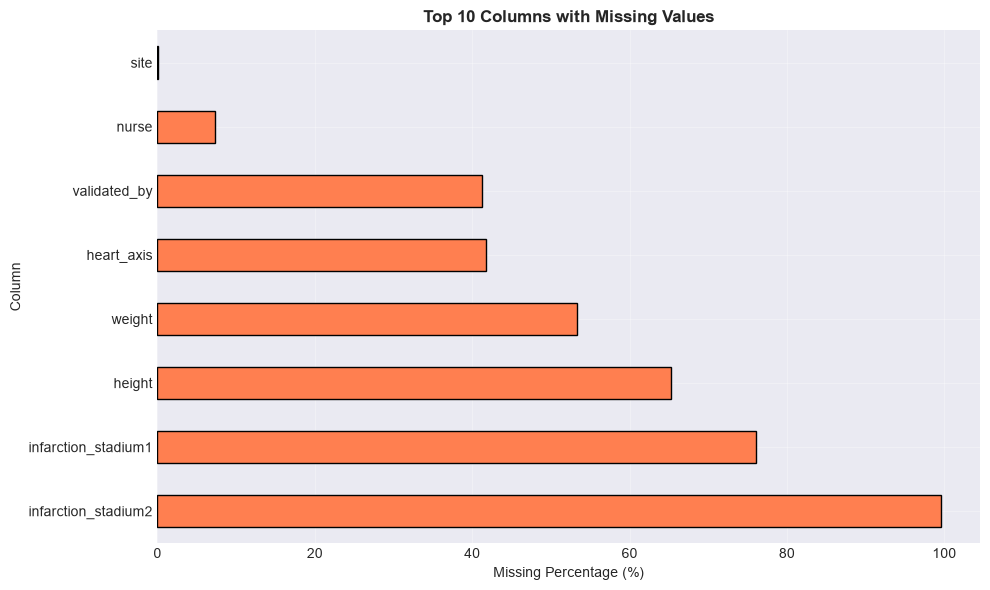

In [51]:
print("="*70)
print("MISSING VALUES ANALYSIS")
print("="*70)

missing_stats = pd.DataFrame({
    'Missing_Count': df.isnull().sum(),
    'Missing_Percent': (df.isnull().sum() / len(df)) * 100
}).sort_values('Missing_Count', ascending=False)

missing_cols = missing_stats[missing_stats['Missing_Count'] > 0]

if len(missing_cols) > 0:
    print(f"\nColumns with Missing Values ({len(missing_cols)} of {len(df.columns)}):")
    for col, row in missing_cols.iterrows():
        print(f"  {col:30s}: {int(row['Missing_Count']):6,} ({row['Missing_Percent']:5.2f}%)")

    fig, ax = plt.subplots(figsize=(10, 6))
    missing_cols.nlargest(10, 'Missing_Percent')['Missing_Percent'].plot(
        kind='barh', ax=ax, color='coral', edgecolor='black'
    )
    ax.set_xlabel('Missing Percentage (%)')
    ax.set_ylabel('Column')
    ax.set_title('Top 10 Columns with Missing Values', fontweight='bold')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("\nNo missing values!")

### 5.3 Statistical Summary

In [52]:
print("="*70)
print("STATISTICAL SUMMARY")
print("="*70)

key_features = ['age', 'sex', 'height', 'weight']
available_features = [f for f in key_features if f in df.columns]

if available_features:
    print(f"\nDescriptive Statistics:")
    print(df[available_features].describe().round(2))

STATISTICAL SUMMARY

Descriptive Statistics:
            age       sex   height   weight
count  18569.00  18569.00  6460.00  8663.00
mean      59.14      0.49   167.06    71.31
std       16.94      0.50    10.13    15.58
min        3.00      0.00    66.00    20.00
25%       49.00      0.00   160.00    60.00
50%       61.00      0.00   167.00    70.00
75%       72.00      1.00   175.00    80.00
max       89.00      1.00   209.00   250.00


### 5.4 Patient Demographics

In [53]:
print("="*70)
print("PATIENT DEMOGRAPHICS")
print("="*70)

if 'age' in df.columns:
    print(f"\nAge Distribution:")
    print(f"  Mean:   {df['age'].mean():.1f} years")
    print(f"  Median: {df['age'].median():.1f} years")
    print(f"  Std:    {df['age'].std():.1f} years")
    print(f"  Range:  {df['age'].min():.0f} - {df['age'].max():.0f} years")

if 'sex' in df.columns:
    print(f"\nSex Distribution:")
    sex_counts = df['sex'].value_counts()
    for sex, count in sex_counts.items():
        sex_label = 'Male' if sex == 1 else 'Female'
        pct = (count / len(df)) * 100
        print(f"  {sex_label:10s}: {count:6,} ({pct:5.2f}%)")

if 'height' in df.columns:
    height_valid = df['height'].dropna()
    if len(height_valid) > 0:
        print(f"\nHeight (n={len(height_valid):,}):")
        print(f"  Mean: {height_valid.mean():.1f} cm")
        print(f"  Range: {height_valid.min():.0f} - {height_valid.max():.0f} cm")

if 'weight' in df.columns:
    weight_valid = df['weight'].dropna()
    if len(weight_valid) > 0:
        print(f"\nWeight (n={len(weight_valid):,}):")
        print(f"  Mean: {weight_valid.mean():.1f} kg")
        print(f"  Range: {weight_valid.min():.0f} - {weight_valid.max():.0f} kg")

PATIENT DEMOGRAPHICS

Age Distribution:
  Mean:   59.1 years
  Median: 61.0 years
  Std:    16.9 years
  Range:  3 - 89 years

Sex Distribution:
  Female    :  9,561 (51.49%)
  Male      :  9,008 (48.51%)

Height (n=6,460):
  Mean: 167.1 cm
  Range: 66 - 209 cm

Weight (n=8,663):
  Mean: 71.3 kg
  Range: 20 - 250 kg


### 5.5 Demographic Visualizations

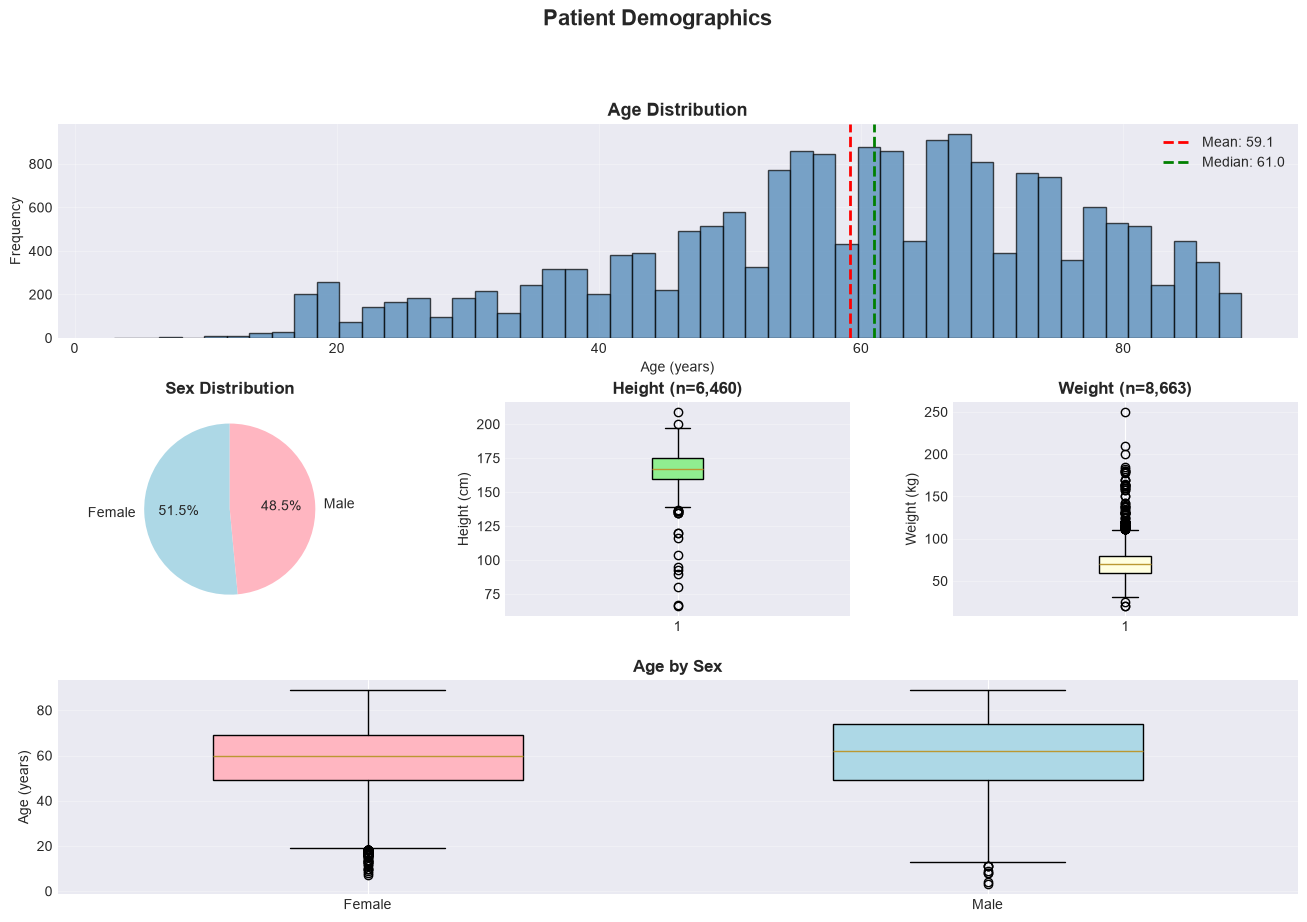

In [54]:
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# Age Histogram
if 'age' in df.columns:
    ax1 = fig.add_subplot(gs[0, :])
    df['age'].hist(bins=50, ax=ax1, color='steelblue', edgecolor='black', alpha=0.7)
    ax1.axvline(df['age'].mean(), color='red', linestyle='--', linewidth=2,
                label=f"Mean: {df['age'].mean():.1f}")
    ax1.axvline(df['age'].median(), color='green', linestyle='--', linewidth=2,
                label=f"Median: {df['age'].median():.1f}")
    ax1.set_xlabel('Age (years)')
    ax1.set_ylabel('Frequency')
    ax1.set_title('Age Distribution', fontweight='bold', fontsize=13)
    ax1.legend()
    ax1.grid(True, alpha=0.3)

# Sex Pie Chart
if 'sex' in df.columns:
    ax2 = fig.add_subplot(gs[1, 0])
    sex_counts = df['sex'].value_counts()
    labels = ['Male' if x == 1 else 'Female' for x in sex_counts.index]
    colors = ['lightblue', 'lightpink']
    ax2.pie(sex_counts.values, labels=labels, autopct='%1.1f%%',
            colors=colors, startangle=90)
    ax2.set_title('Sex Distribution', fontweight='bold')

# Height Box Plot
if 'height' in df.columns:
    ax3 = fig.add_subplot(gs[1, 1])
    height_valid = df['height'].dropna()
    if len(height_valid) > 0:
        bp = ax3.boxplot(height_valid, vert=True, patch_artist=True)
        bp['boxes'][0].set_facecolor('lightgreen')
        ax3.set_ylabel('Height (cm)')
        ax3.set_title(f'Height (n={len(height_valid):,})', fontweight='bold')
        ax3.grid(True, alpha=0.3, axis='y')

# Weight Box Plot
if 'weight' in df.columns:
    ax4 = fig.add_subplot(gs[1, 2])
    weight_valid = df['weight'].dropna()
    if len(weight_valid) > 0:
        bp = ax4.boxplot(weight_valid, vert=True, patch_artist=True)
        bp['boxes'][0].set_facecolor('lightyellow')
        ax4.set_ylabel('Weight (kg)')
        ax4.set_title(f'Weight (n={len(weight_valid):,})', fontweight='bold')
        ax4.grid(True, alpha=0.3, axis='y')

# Age by Sex
if 'age' in df.columns and 'sex' in df.columns:
    ax5 = fig.add_subplot(gs[2, :])
    age_by_sex = [df[df['sex'] == 0]['age'].dropna(),
                  df[df['sex'] == 1]['age'].dropna()]
    bp = ax5.boxplot(age_by_sex, tick_labels=['Female', 'Male'],
                     patch_artist=True, widths=0.5)
    bp['boxes'][0].set_facecolor('lightpink')
    bp['boxes'][1].set_facecolor('lightblue')
    ax5.set_ylabel('Age (years)')
    ax5.set_title('Age by Sex', fontweight='bold')
    ax5.grid(True, alpha=0.3, axis='y')

plt.suptitle('Patient Demographics', fontsize=16, fontweight='bold', y=0.995)
plt.show()

### 5.6 Diagnostic Labels Distribution

In [55]:
print("="*70)
print("DIAGNOSTIC LABELS DISTRIBUTION")
print("="*70)

# Check if diagnostic labels exist
superclass_labels = ['NORM', 'MI', 'STTC', 'CD', 'HYP']
existing_labels = [label for label in superclass_labels if label in df.columns]

if existing_labels:
    print(f"\nDiagnostic Superclasses ({len(existing_labels)} classes):")
    print("-"*70)

    label_counts = {}
    for label in existing_labels:
        count = df[label].sum()
        pct = (count / len(df)) * 100
        label_counts[label] = count
        print(f"  {label:10s}: {count:6,} records ({pct:5.2f}%)")

    # Multi-label analysis
    if 'num_labels' in df.columns:
        print(f"\nMulti-label Distribution:")
        print(df['num_labels'].value_counts().sort_index())
    else:
        df['num_labels'] = df[existing_labels].sum(axis=1)
        print(f"\nMulti-label Distribution:")
        print(df['num_labels'].value_counts().sort_index())

    # Visualize label distribution
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Bar chart of label counts
    ax1 = axes[0]
    label_data = pd.Series(label_counts).sort_values(ascending=False)
    label_data.plot(kind='bar', ax=ax1, color='steelblue', edgecolor='black')
    ax1.set_xlabel('Diagnostic Class')
    ax1.set_ylabel('Count')
    ax1.set_title('Diagnostic Label Distribution', fontweight='bold')
    ax1.set_xticklabels(['NORM\n(Normal)', 'MI\n(MI)', 'STTC\n(ST/T)',
                         'CD\n(Conduction)', 'HYP\n(Hypertrophy)'], rotation=0)
    for i, v in enumerate(label_data.values):
        ax1.text(i, v + 100, str(v), ha='center', fontweight='bold')
    ax1.grid(True, alpha=0.3, axis='y')

    # Multi-label distribution
    ax2 = axes[1]
    df['num_labels'].value_counts().sort_index().plot(kind='bar', ax=ax2,
                                                        color='coral', edgecolor='black')
    ax2.set_xlabel('Number of Labels per Record')
    ax2.set_ylabel('Count')
    ax2.set_title('Multi-label Distribution', fontweight='bold')
    ax2.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()
else:
    print("\nDiagnostic labels not found - run Section 4 first")

print("="*70)

DIAGNOSTIC LABELS DISTRIBUTION

Diagnostic labels not found - run Section 4 first


### 5.7 Signal Quality Indicators Analysis

SIGNAL QUALITY INDICATORS

Quality Issues Summary:
----------------------------------------------------------------------
  baseline_drift           : 1,368 ( 7.37%)
  static_noise             : 2,668 (14.37%)
  burst_noise              :   503 ( 2.71%)
  electrodes_problems      :    27 ( 0.15%)
  extra_beats              : 1,489 ( 8.02%)
  pacemaker                :   223 ( 1.20%)

Records by Quality Issue Count:
total_quality_issues
0    13205
1     4519
2      780
3       61
4        4
Name: count, dtype: int64


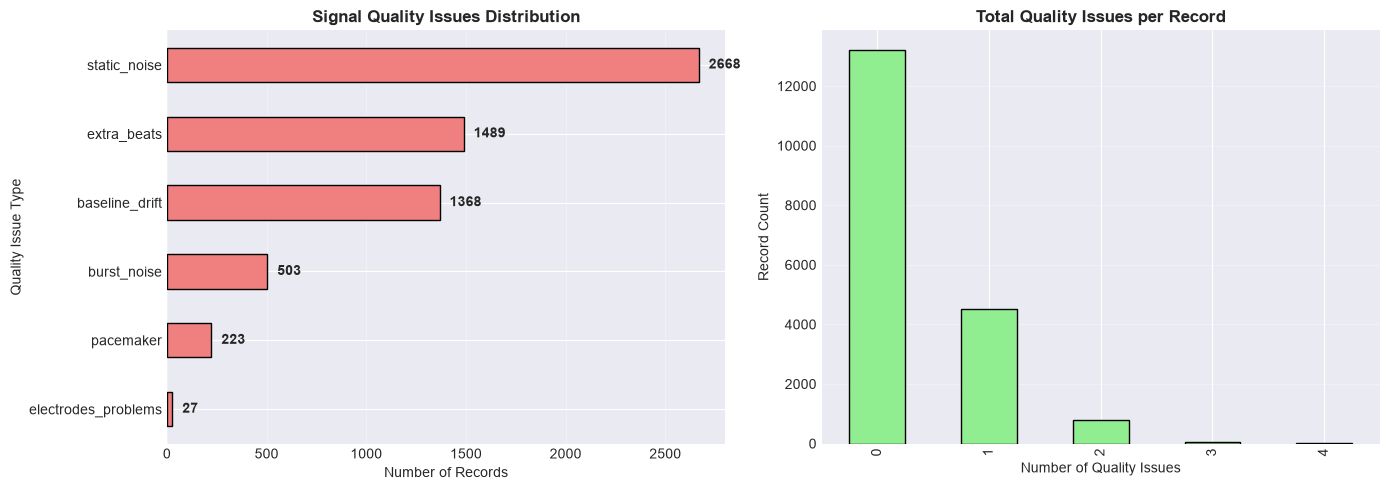

In [56]:
print("="*70)
print("SIGNAL QUALITY INDICATORS")
print("="*70)

quality_cols = ['baseline_drift', 'static_noise', 'burst_noise',
                'electrodes_problems', 'extra_beats', 'pacemaker']
existing_quality = [col for col in quality_cols if col in df.columns]

if existing_quality:
    print(f"\nQuality Issues Summary:")
    print("-"*70)

    quality_stats = {}
    for col in existing_quality:
        # Count non-zero values (issues present)
        if df[col].dtype == 'object':
            issue_count = (df[col] != 0).sum()
        else:
            issue_count = df[col].sum()

        pct = (issue_count / len(df)) * 100
        quality_stats[col] = issue_count
        print(f"  {col:25s}: {issue_count:5,} ({pct:5.2f}%)")

    # Calculate total quality score
    df['total_quality_issues'] = 0
    for col in existing_quality:
        if df[col].dtype == 'object':
            df['total_quality_issues'] += (df[col] != 0).astype(int)
        else:
            df['total_quality_issues'] += df[col]

    print(f"\nRecords by Quality Issue Count:")
    print(df['total_quality_issues'].value_counts().sort_index())

    # Visualize quality issues
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Horizontal bar chart
    ax1 = axes[0]
    quality_data = pd.Series(quality_stats).sort_values(ascending=True)
    quality_data.plot(kind='barh', ax=ax1, color='lightcoral', edgecolor='black')
    ax1.set_xlabel('Number of Records')
    ax1.set_ylabel('Quality Issue Type')
    ax1.set_title('Signal Quality Issues Distribution', fontweight='bold')
    for i, v in enumerate(quality_data.values):
        ax1.text(v + 50, i, str(v), va='center', fontweight='bold')
    ax1.grid(True, alpha=0.3, axis='x')

    # Total issues distribution
    ax2 = axes[1]
    df['total_quality_issues'].value_counts().sort_index().plot(kind='bar',
                                                                  ax=ax2, color='lightgreen',
                                                                  edgecolor='black')
    ax2.set_xlabel('Number of Quality Issues')
    ax2.set_ylabel('Record Count')
    ax2.set_title('Total Quality Issues per Record', fontweight='bold')
    ax2.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()
else:
    print("\nQuality columns not found")

print("="*70)

### 5.8 Feature Correlation Analysis

CORRELATION ANALYSIS

Correlation Matrix (4 features):
          age    sex  height  weight
age     1.000  0.041  -0.171  -0.081
sex     0.041  1.000  -0.615  -0.438
height -0.171 -0.615   1.000   0.544
weight -0.081 -0.438   0.544   1.000


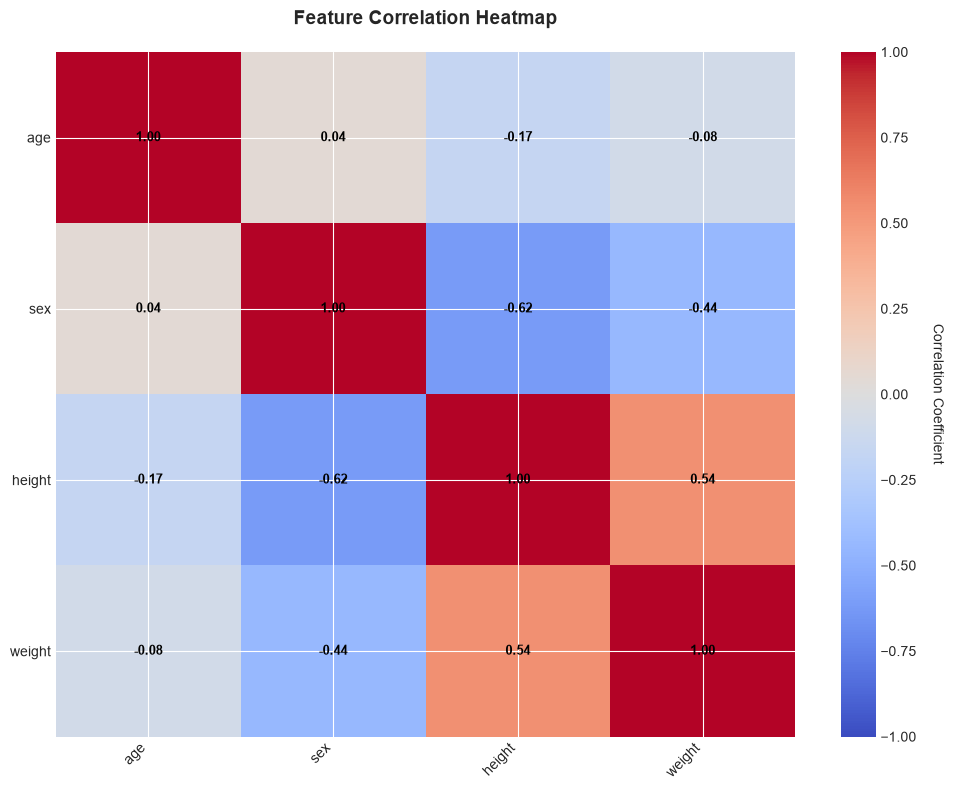


Strong Correlations (|r| > 0.5):
----------------------------------------------------------------------
  sex        <-> height    : -0.615
  height     <-> weight    :  0.544



In [57]:
print("="*70)
print("CORRELATION ANALYSIS")
print("="*70)

# Select numerical features for correlation
numerical_features = ['age', 'sex', 'height', 'weight']
existing_numerical = [f for f in numerical_features if f in df.columns]

# Add diagnostic labels if they exist
superclass_labels = ['NORM', 'MI', 'STTC', 'CD', 'HYP']
existing_labels = [label for label in superclass_labels if label in df.columns]
existing_numerical.extend(existing_labels)

if len(existing_numerical) > 1:
    # Calculate correlation matrix
    corr_matrix = df[existing_numerical].corr()

    print(f"\nCorrelation Matrix ({len(existing_numerical)} features):")
    print(corr_matrix.round(3))

    # Visualize correlation heatmap
    fig, ax = plt.subplots(figsize=(10, 8))

    im = ax.imshow(corr_matrix, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)

    # Set ticks and labels
    ax.set_xticks(range(len(existing_numerical)))
    ax.set_yticks(range(len(existing_numerical)))
    ax.set_xticklabels(existing_numerical, rotation=45, ha='right')
    ax.set_yticklabels(existing_numerical)

    # Add colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Correlation Coefficient', rotation=270, labelpad=20)

    # Add correlation values to cells
    for i in range(len(existing_numerical)):
        for j in range(len(existing_numerical)):
            text = ax.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}',
                          ha='center', va='center', color='black',
                          fontsize=9, fontweight='bold')

    ax.set_title('Feature Correlation Heatmap', fontweight='bold', fontsize=14, pad=20)
    plt.tight_layout()
    plt.show()

    # Find strong correlations
    print(f"\nStrong Correlations (|r| > 0.5):")
    print("-"*70)
    strong_corr = []
    for i in range(len(corr_matrix)):
        for j in range(i+1, len(corr_matrix)):
            corr_val = corr_matrix.iloc[i, j]
            if abs(corr_val) > 0.5:
                feat1 = existing_numerical[i]
                feat2 = existing_numerical[j]
                strong_corr.append((feat1, feat2, corr_val))
                print(f"  {feat1:10s} <-> {feat2:10s}: {corr_val:6.3f}")

    if not strong_corr:
        print("  No strong correlations found")
else:
    print("\nNot enough features for correlation analysis")

print("\n" + "="*70)

### 5.9 EDA Summary and Key Findings

In [58]:
print("="*70)
print("EDA SUMMARY - KEY FINDINGS")
print("="*70)

print(f"\n1. DATASET SIZE:")
print(f"   - Total ECG records: {len(df):,}")
print(f"   - Unique patients: {df['patient_id'].nunique():,}")
print(f"   - Features: {len(df.columns)}")

if 'age' in df.columns:
    print(f"\n2. PATIENT DEMOGRAPHICS:")
    print(f"   - Age: {df['age'].mean():.1f} ± {df['age'].std():.1f} years")
    print(f"   - Age range: {df['age'].min():.0f} - {df['age'].max():.0f} years")

if 'sex' in df.columns:
    sex_counts = df['sex'].value_counts()
    male_pct = (sex_counts.get(1, 0) / len(df)) * 100
    female_pct = (sex_counts.get(0, 0) / len(df)) * 100
    print(f"   - Sex: {male_pct:.1f}% Male, {female_pct:.1f}% Female")

superclass_labels = ['NORM', 'MI', 'STTC', 'CD', 'HYP']
existing_labels = [label for label in superclass_labels if label in df.columns]

if existing_labels:
    print(f"\n3. DIAGNOSTIC LABELS:")
    for label in existing_labels:
        count = df[label].sum()
        pct = (count / len(df)) * 100
        print(f"   - {label:10s}: {count:6,} ({pct:5.2f}%)")

    if 'num_labels' in df.columns:
        multi_label_pct = (df['num_labels'] > 1).sum() / len(df) * 100
        print(f"   - Multi-label records: {multi_label_pct:.1f}%")

quality_cols = ['baseline_drift', 'static_noise', 'burst_noise',
                'electrodes_problems', 'extra_beats']
existing_quality = [col for col in quality_cols if col in df.columns]

if existing_quality:
    print(f"\n4. SIGNAL QUALITY:")
    any_issue = 0
    for col in existing_quality:
        if df[col].dtype == 'object':
            issue_count = (df[col] != 0).sum()
        else:
            issue_count = df[col].sum()
        any_issue += (df[col] != 0).astype(int)

    records_with_issues = (any_issue > 0).sum()
    pct_with_issues = (records_with_issues / len(df)) * 100
    print(f"   - Records with quality issues: {records_with_issues:,} ({pct_with_issues:.1f}%)")
    print(f"   - Clean records: {len(df) - records_with_issues:,} ({100-pct_with_issues:.1f}%)")

# Missing data summary
missing_cols = df.columns[df.isnull().any()].tolist()
if missing_cols:
    print(f"\n5. MISSING DATA:")
    print(f"   - Columns with missing values: {len(missing_cols)}")
    top_missing = df.isnull().sum().nlargest(3)
    for col, count in top_missing.items():
        if count > 0:
            pct = (count / len(df)) * 100
            print(f"   - {col:20s}: {count:6,} ({pct:5.2f}%)")

print(f"\n6. DATA QUALITY:")
print(f"   - Data types: {df.dtypes.nunique()} unique types")
print(f"   - Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print(f"\n" + "="*70)
print("EDA COMPLETE - Ready for preprocessing and modeling!")
print("="*70)

EDA SUMMARY - KEY FINDINGS

1. DATASET SIZE:
   - Total ECG records: 18,569
   - Unique patients: 18,569
   - Features: 28

2. PATIENT DEMOGRAPHICS:
   - Age: 59.1 ± 16.9 years
   - Age range: 3 - 89 years
   - Sex: 48.5% Male, 51.5% Female

4. SIGNAL QUALITY:
   - Records with quality issues: 5,216 (28.1%)
   - Clean records: 13,353 (71.9%)

5. MISSING DATA:
   - Columns with missing values: 8
   - infarction_stadium2 : 18,487 (99.56%)
   - infarction_stadium1 : 14,120 (76.04%)
   - height              : 12,109 (65.21%)

6. DATA QUALITY:
   - Data types: 5 unique types
   - Memory usage: 10.78 MB

EDA COMPLETE - Ready for preprocessing and modeling!


## 4. Diagnostic Labels Analysis

In [59]:
# Load SCP statements
scp_statements = pd.read_csv(DATA_PATH / 'scp_statements.csv', index_col=0)
print(f"Total diagnostic statements: {len(scp_statements)}")
print(f"\nSCP Statements (first 10):")
scp_statements.head(10)

Total diagnostic statements: 71

SCP Statements (first 10):


,description,diagnostic,form,rhythm,diagnostic_class,diagnostic_subclass,Statement Category,SCP-ECG Statement Description,AHA code,aECG REFID,CDISC Code,DICOM Code
NDT,non-diagnostic T abnormalities,1.0,1.0,NaN,STTC,STTC,other ST-T descriptive statements,non-diagnostic T abnormalities,NaN,NaN,NaN,NaN
NST_,non-specific ST changes,1.0,1.0,NaN,STTC,NST_,Basic roots for coding ST-T changes and abnorm...,non-specific ST changes,145.0,MDC_ECG_RHY_STHILOST,NaN,NaN
DIG,digitalis-effect,1.0,1.0,NaN,STTC,STTC,other ST-T descriptive statements,suggests digitalis-effect,205.0,NaN,NaN,NaN
LNGQT,long QT-interval,1.0,1.0,NaN,STTC,STTC,other ST-T descriptive statements,long QT-interval,148.0,NaN,NaN,NaN
NORM,normal ECG,1.0,NaN,NaN,NORM,NORM,Normal/abnormal,normal ECG,1.0,NaN,NaN,F-000B7
IMI,inferior myocardial infarction,1.0,NaN,NaN,MI,IMI,Myocardial Infarction,inferior myocardial infarction,161.0,NaN,NaN,NaN
ASMI,anteroseptal myocardial infarction,1.0,NaN,NaN,MI,AMI,Myocardial Infarction,anteroseptal myocardial infarction,165.0,NaN,NaN,NaN
LVH,left ventricular hypertrophy,1.0,NaN,NaN,HYP,LVH,Ventricular Hypertrophy,left ventricular hypertrophy,142.0,NaN,C71076,NaN
LAFB,left anterior fascicular block,1.0,NaN,NaN,CD,LAFB/LPFB,Intraventricular and intra-atrial Conduction d...,left anterior fascicular block,101.0,MDC_ECG_BEAT_BLK_ANT_L_HEMI,C62267,D3-33140
ISC_,non-specific ischemic,1.0,NaN,NaN,STTC,ISC_,Basic roots for coding ST-T changes and abnorm...,ischemic ST-T changes,226.0,NaN,NaN,NaN


In [60]:
# Parse SCP codes
df['scp_codes_dict'] = df['scp_codes'].apply(lambda x: ast.literal_eval(x))

# Map to diagnostic classes
def aggregate_diagnostic(scp_dict):
    agg_dict = {}
    for key in scp_dict.keys():
        if key in scp_statements.index:
            diag_class = scp_statements.loc[key, 'diagnostic_class']
            if pd.notna(diag_class):
                agg_dict[diag_class] = 1
    return agg_dict

df['diagnostic_superclass'] = df['scp_codes_dict'].apply(aggregate_diagnostic)

# Extract superclass labels
superclass_labels = ['NORM', 'MI', 'STTC', 'CD', 'HYP']
for label in superclass_labels:
    df[label] = df['diagnostic_superclass'].apply(lambda x: 1 if label in x else 0)

print("Superclass Labels Distribution:")
for label in superclass_labels:
    print(f"{label}: {df[label].sum()}")

Superclass Labels Distribution:
NORM: 8646
MI: 4352
STTC: 4191
CD: 3978
HYP: 2183
